In [ ]:
!pip install sunpy astropy scikit-image -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 834.8 kB/s eta 0:00:00


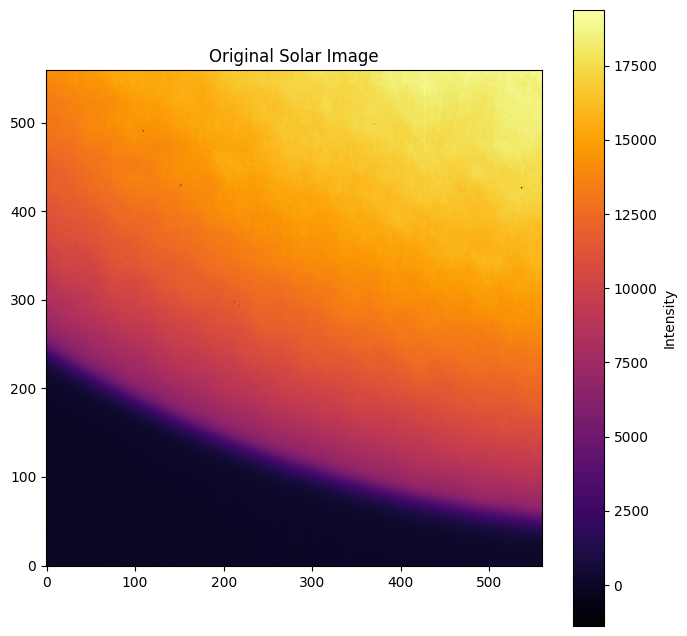

In [ ]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

filename = "SUT_T26_0723_002181_Lev1.0_2026-05-25T21.09.53.750_0973NB07.fits"

hdul = fits.open(filename)

img = None
for hdu in hdul:
    if hdu.data is not None and len(hdu.data.shape) >= 2:
        img = hdu.data.astype(float)
        break

hdul.close()

img = np.nan_to_num(img)

plt.figure(figsize=(8,8))
plt.imshow(img, cmap="inferno", origin="lower")
plt.title("Original Solar Image")
plt.colorbar(label="Intensity")
plt.show()

/tmp/ipykernel_1201/2115407848.py:11: RuntimeWarning: divide by zero encountered in log1p
  img_log = np.log1p(img_clip)
/tmp/ipykernel_1201/2115407848.py:11: RuntimeWarning: invalid value encountered in log1p
  img_log = np.log1p(img_clip)


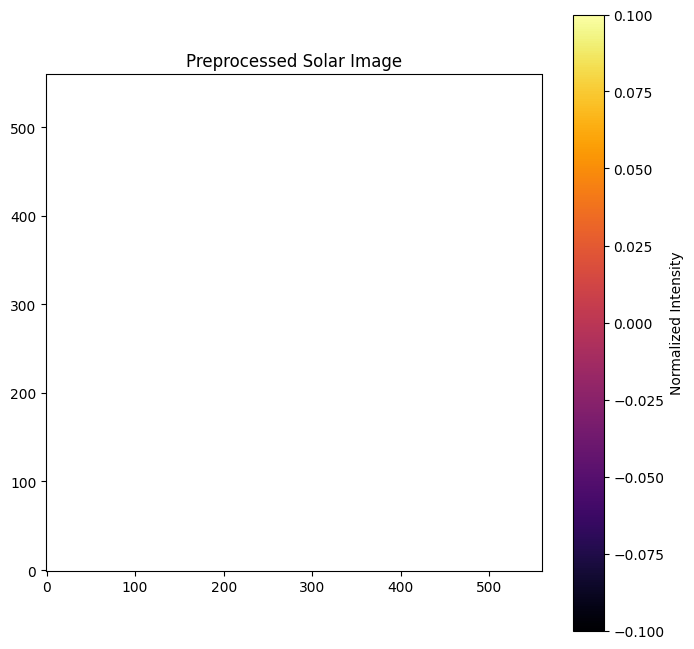

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Remove invalid values
img = np.nan_to_num(img)

# Clip intensity values
img_clip = np.clip(img, np.percentile(img, 1), np.percentile(img, 99))

# Apply logarithmic scaling
img_log = np.log1p(img_clip)

# Normalize image
img_norm = (img_log - img_log.min()) / (img_log.max() - img_log.min())

# Display processed image
plt.figure(figsize=(8,8))
plt.imshow(img_norm, cmap='inferno', origin='lower')
plt.title("Preprocessed Solar Image")
plt.colorbar(label="Normalized Intensity")
plt.show()

In [ ]:
from astropy.io import fits

import numpy as np

import matplotlib.pyplot as plt

# Reload the image

filename = "SUT_T26_0723_002181_Lev1.0_2026-05-25T21.09.53.750_0973NB07.fits"

hdul = fits.open(filename)

img = None

for hdu in hdul:

if hdu.data is not None and len(hdu.data.shape) >= 2:

img = hdu.data.astype(float)

break

hdul.close()

# Remove invalid values

img = np.nan_to_num(img)

# Shift image so minimum becomes zero

img_shift = img - img.min()

# Clip extreme values

img_clip = np.clip(img_shift,

np.percentile(img_shift, 1),

np.percentile(img_shift, 99))

# Log scaling

img_log = np.log1p(img_clip)

# Normalize

img_norm = (img_log - img_log.min()) / (img_log.max() - img_log.min())

# Display

plt.figure(figsize=(8,8))

plt.imshow(img_norm, cmap='inferno', origin='lower')

plt.title("Preprocessed Solar Image")

plt.colorbar(label="Normalized Intensity")

plt.show()

IndentationError: expected an indented block after 'for' statement on line 15 (1679205957.py, line 17)

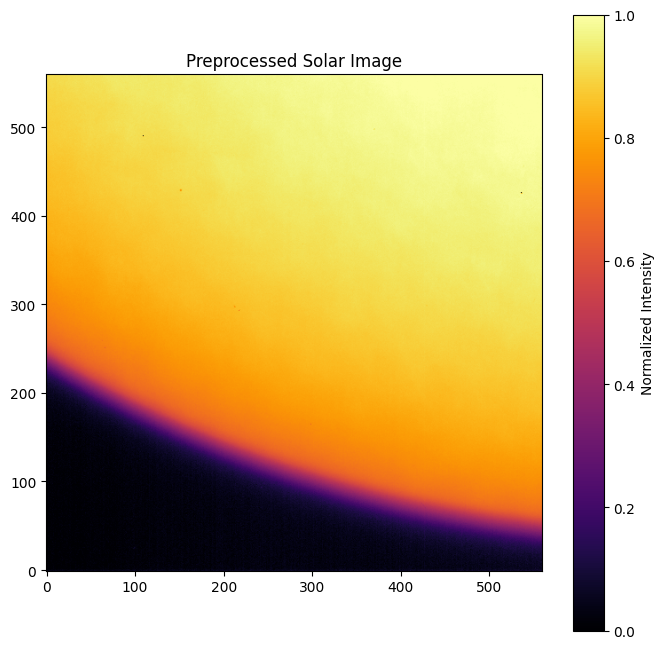

In [ ]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Load FITS file
filename = "SUT_T26_0723_002181_Lev1.0_2026-05-25T21.09.53.750_0973NB07.fits"

hdul = fits.open(filename)

img = None

for hdu in hdul:
    if hdu.data is not None:
        if len(hdu.data.shape) >= 2:
            img = hdu.data.astype(float)
            break

hdul.close()

# Remove invalid values
img = np.nan_to_num(img)

# Shift image so minimum becomes zero
img = img - np.min(img)

# Clip intensity
img = np.clip(img,
              np.percentile(img, 1),
              np.percentile(img, 99))

# Log transform
img = np.log1p(img)

# Normalize
img = (img - img.min()) / (img.max() - img.min())

# Display
plt.figure(figsize=(8,8))
plt.imshow(img, cmap='inferno', origin='lower')
plt.title("Preprocessed Solar Image")
plt.colorbar(label="Normalized Intensity")
plt.show()

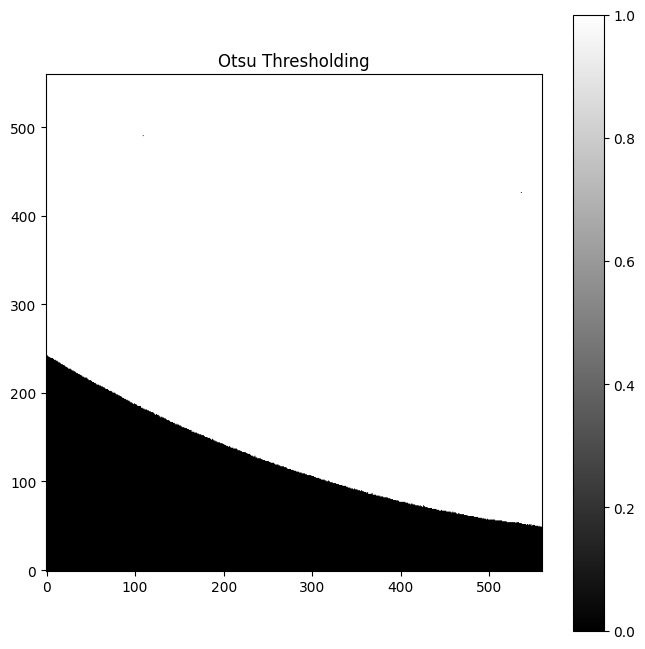

In [ ]:
from skimage.filters import threshold_otsu

# Calculate Otsu threshold
thresh = threshold_otsu(img)

# Create binary image
otsu = img > thresh

# Display
plt.figure(figsize=(8,8))
plt.imshow(otsu, cmap='gray', origin='lower')
plt.title("Otsu Thresholding")
plt.colorbar()
plt.show()

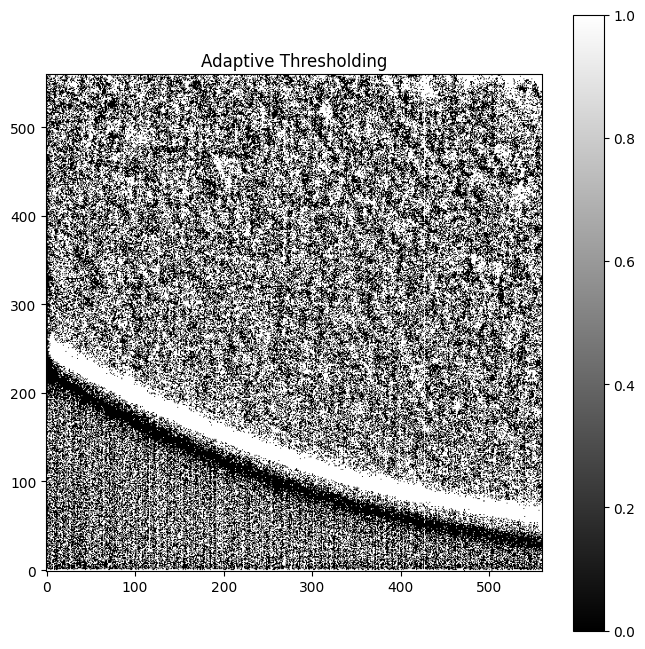

In [ ]:
from skimage.filters import threshold_local

# Adaptive threshold
block_size = 35
adaptive_thresh = threshold_local(img, block_size, offset=0)

adaptive = img > adaptive_thresh

# Display
plt.figure(figsize=(8,8))
plt.imshow(adaptive, cmap='gray', origin='lower')
plt.title("Adaptive Thresholding")
plt.colorbar()
plt.show()

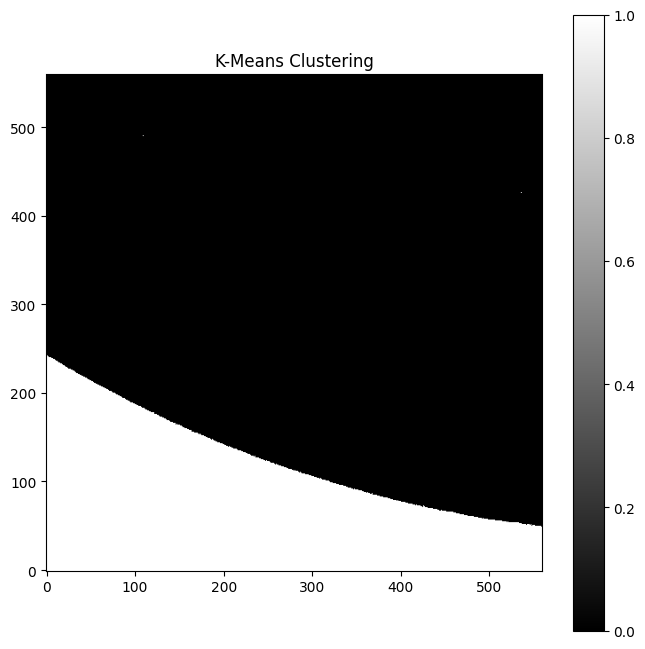

In [ ]:
from sklearn.cluster import KMeans

# Reshape image into a column vector
pixels = img.reshape((-1, 1))

# Apply K-Means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)

# Reshape back to image
clustered = labels.reshape(img.shape)

# Display
plt.figure(figsize=(8,8))
plt.imshow(clustered, cmap='gray', origin='lower')
plt.title("K-Means Clustering")
plt.colorbar()
plt.show()

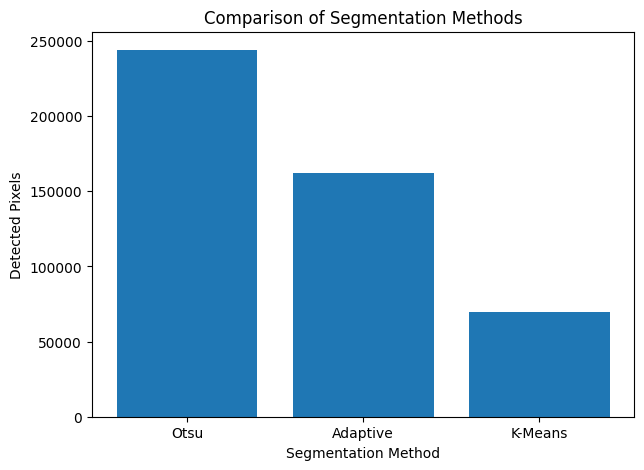

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count detected pixels
otsu_pixels = np.sum(otsu)
adaptive_pixels = np.sum(adaptive)
kmeans_pixels = np.sum(clustered)

methods = ['Otsu', 'Adaptive', 'K-Means']
pixels = [otsu_pixels, adaptive_pixels, kmeans_pixels]

plt.figure(figsize=(7,5))
plt.bar(methods, pixels)
plt.xlabel("Segmentation Method")
plt.ylabel("Detected Pixels")
plt.title("Comparison of Segmentation Methods")
plt.show()

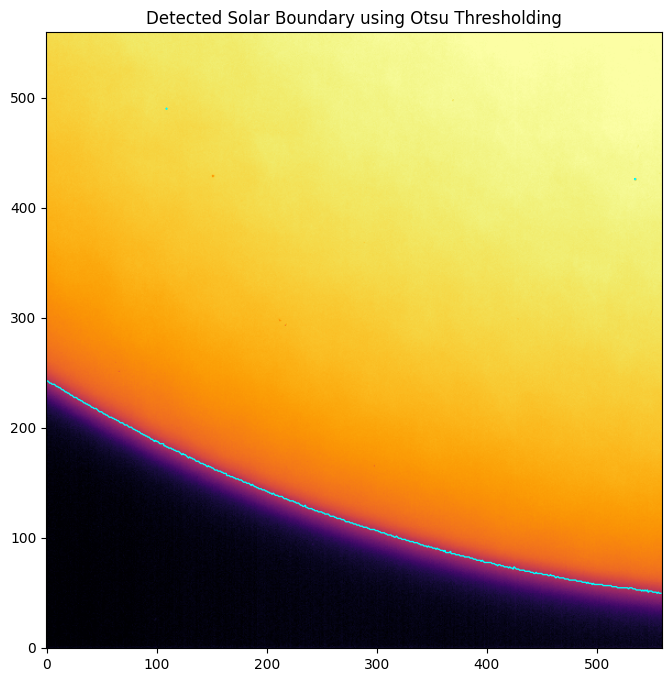

In [ ]:
from skimage import measure

plt.figure(figsize=(8,8))
plt.imshow(img, cmap='inferno', origin='lower')

# Draw contour around the Otsu segmentation
plt.contour(otsu, colors='cyan', linewidths=1)

plt.title("Detected Solar Boundary using Otsu Thresholding")
plt.show()